In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# --- PENTING: PASTIKAN FILE rl_training_data.csv ADA DI DIREKTORI INI ---

def animate_robot_movement(file_path):
    """
    Membuat animasi pergerakan robot dari data CSV.
    
    Args:
        file_path (str): Lokasi file CSV.
    """
    try:
        # 1. Membaca Data
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"ERROR: File '{file_path}' tidak ditemukan. Pastikan file ada dan namanya benar.")
        return

    # Inisialisasi list untuk menyimpan jalur robot (history)
    robot_path_x = []
    robot_path_y = []

    print(f"Memulai animasi pergerakan robot dari {len(df)} langkah data...")
    print("------------------------------------------------------------------")

    # Tentukan batas plot (berdasarkan nilai min/max pada seluruh data, ditambah buffer)
    # Ini penting agar plot tidak berganti skala di setiap frame
    x_min = df[['robot_x', 'nearest_waste_x']].min().min() - 5
    x_max = df[['robot_x', 'nearest_waste_x']].max().max() + 5
    y_min = df[['robot_y', 'nearest_waste_y']].min().min() - 5
    y_max = df[['robot_y', 'nearest_waste_y']].max().max() + 5

    # 2. Loop Melalui Setiap Baris Data (Simulasi Langkah Demi Langkah)
    for index, row in df.iterrows():
        
        # Ambil data dari baris saat ini
        robot_x = row['robot_x']
        robot_y = row['robot_y']
        nearest_waste_x = row['nearest_waste_x']
        nearest_waste_y = row['nearest_waste_y']
        distance = row['distance']
        description = row['description']
        
        # Tambahkan posisi robot saat ini ke history jalur
        robot_path_x.append(robot_x)
        robot_path_y.append(robot_y)

        # ------------------------------------------------
        # 3. Hapus Output Sebelumnya
        clear_output(wait=True)
        
        # 4. Gambar Plot Baru
        plt.figure(figsize=(10, 6), facecolor='#0D2235') # Memberi warna latar belakang gelap
        ax = plt.gca()
        ax.set_facecolor('#0D2235')
        ax.tick_params(axis='x', colors='white')
        ax.tick_params(axis='y', colors='white')
        
        # Plot Jalur Pergerakan Robot (Path)
        plt.plot(robot_path_x, robot_path_y, 
                 linestyle='-', 
                 color='#4CAF50', 
                 alpha=0.6, 
                 label='Robot Path')
        
        # Plot Titik Sampah Terdekat (Nearest Trash)
        plt.plot(nearest_waste_x, nearest_waste_y, 
                 'o', 
                 color='green', 
                 markersize=10, 
                 label='Nearest Trash')
        plt.text(nearest_waste_x + 0.5, nearest_waste_y, 
                 f'({nearest_waste_x}, {nearest_waste_y})', 
                 color='green', fontsize=10)

        # Plot Titik Robot Saat Ini (Current Robot)
        plt.plot(robot_x, robot_y, 
                 'o', 
                 color='red', 
                 markersize=12, 
                 label='Current Robot')
        plt.text(robot_x + 0.5, robot_y, 
                 f'Robot ({robot_x}, {robot_y})', 
                 color='red', fontsize=10)
        
        # Garis Jarak ke Sampah (Opsional)
        plt.plot([robot_x, nearest_waste_x], [robot_y, nearest_waste_y], 
                 '--', 
                 color='yellow', 
                 alpha=0.7)
        plt.text((robot_x + nearest_waste_x) / 2, 
                 (robot_y + nearest_waste_y) / 2, 
                 f'Jarak: {distance:.2f}', 
                 color='yellow', 
                 fontsize=8, 
                 bbox=dict(facecolor='#0D2235', alpha=0.5, edgecolor='none'))

        # Pengaturan Plot
        plt.title(f'Visualisasi Pergerakan Robot - Langkah {row["step"]} dari Episode {row["episode"]}', color='white')
        plt.xlabel('X-Coordinate', color='white')
        plt.ylabel('Y-Coordinate', color='white')
        
        # Tetapkan Batas Plot Agar Konsisten
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.grid(True, linestyle=':', alpha=0.5, color='gray')
        plt.legend()

        # Tambahkan Teks Deskripsi di Bawah Plot
        fig = plt.gcf()
        fig.text(0.1, 0.0, description, fontsize=9, color='white', 
                 verticalalignment='bottom', transform=ax.transAxes)

        # 5. Tampilkan Plot
        display(plt.gcf())
        plt.close() # Tutup figure agar tidak menumpuk di memori
        
        # 6. Jeda Waktu (1 Detik Sesuai Permintaan)
        time.sleep(0.1)
        
    print("------------------------------------------------------------------")
    print("Animasi selesai. Semua data telah divisualisasikan.")

# --- Panggil Fungsi untuk Menjalankan Animasi ---
animate_robot_movement('rl_training_data.csv')

Model DQN dimuat.

image 1/1 c:\Users\Julman Waruwu\Documents\Kuliah semester 5\PJ GEDE\sample_frame.jpg: 448x640 2 PLASTICs, 184.2ms
Speed: 13.4ms preprocess, 184.2ms inference, 6.1ms postprocess per image at shape (1, 3, 448, 640)
image 1/1 c:\Users\Julman Waruwu\Documents\Kuliah semester 5\PJ GEDE\sample_frame.jpg: 448x640 2 PLASTICs, 184.2ms
Speed: 13.4ms preprocess, 184.2ms inference, 6.1ms postprocess per image at shape (1, 3, 448, 640)
## 🖼️ Hasil Inferensi untuk: sample_frame.jpg
**Keputusan Sistem:** **Gerak Barat**
### 🔍 Ringkasan Deteksi (2 total)
**Objek Terdeteksi:** 2 PLASTIC.
### 📋 Detail Deteksi
* Deteksi 1: **PLASTIC**, Confidence: 0.676 (67.6%), BBox: [101, 138, 496, 361]
* Deteksi 2: **PLASTIC**, Confidence: 0.333 (33.3%), BBox: [103, 162, 610, 372]

--- Visualisasi Hasil Deteksi ---
## 🖼️ Hasil Inferensi untuk: sample_frame.jpg
**Keputusan Sistem:** **Gerak Barat**
### 🔍 Ringkasan Deteksi (2 total)
**Objek Terdeteksi:** 2 PLASTIC.
### 📋 Detail Deteksi
* Deteksi 1: *

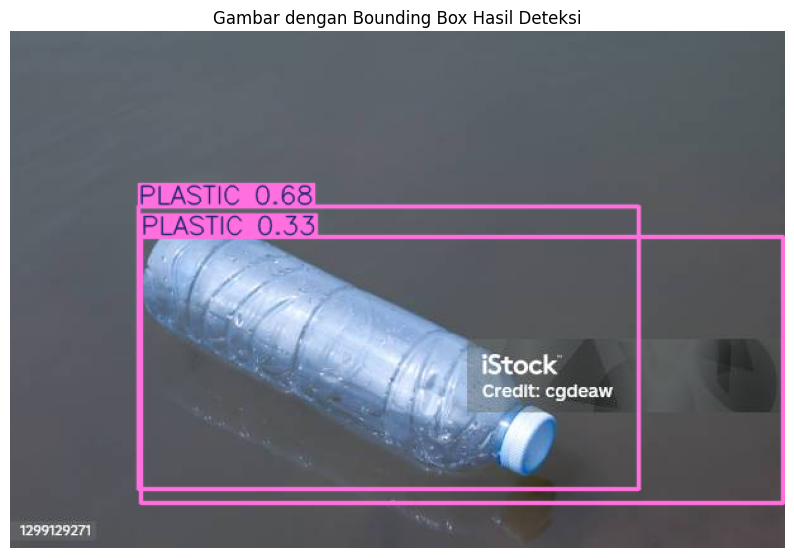

In [12]:
import os
import time
import json
import numpy as np
import torch
from PIL import Image

# ----------------- MOCK CLASSES & DEPENDENCIES -----------------
# Asumsi: Anda memiliki kelas Logger dan QNet yang terdefinisi di tempat lain.
# Untuk menjalankan di notebook tanpa file eksternal, kita buat mock sederhana.

class Logger:
    """Mock class for logging."""
    def __init__(self):
        self.events = []
    def log_event(self, event):
        self.events.append(event)
        # print(f"Logged: {event['decision']['action']}") # Optional: print log

class QNet(torch.nn.Module):
    """Mock QNet class (DQN Agent) for loading state_dict."""
    def __init__(self, state_size=7, action_size=6):
        super().__init__()
        self.fc1 = torch.nn.Linear(state_size, 64)
        self.fc2 = torch.nn.Linear(64, action_size)
    def forward(self, x):
        return self.fc2(torch.nn.functional.relu(self.fc1(x)))
        
# Asumsi transformasi gambar (jika classifier digunakan)
def _transform(img):
    """Mock image transformation for classifier input."""
    from torchvision import transforms
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])(img)
# ----------------------------------------------------------------

# Deteksi: menggunakan ultralytics jika terinstal
try:
    from ultralytics import YOLO
    from matplotlib import pyplot as plt
    yolo_available = True
except ImportError:
    YOLO = None
    plt = None
    print("WARNING: ultralytics (YOLO) atau Matplotlib tidak terinstal. Visualisasi akan terbatas.")
    yolo_available = False


def load_detector(weights_path=None):
    """Load YOLO detector. If weights_path is None, prefer `yolov11n.pt` then `yolov8n.pt`.
    Returns None if ultralytics not available.
    """
    if not yolo_available:
        print("ultralytics YOLO not installed. Detection will be mocked.")
        return None
    
    if weights_path is None:
        if os.path.exists("yolov11n.pt"):
            weights_path = "yolov11n.pt"
        elif os.path.exists("yolov8n.pt"):
            weights_path = "yolov8n.pt"
        else:
            # Gunakan model bawaan (misalnya yolov8n.pt) jika file lokal tidak ditemukan
            weights_path = "yolov8n.pt"
            print(f"Menggunakan model default YOLO: {weights_path}. Pastikan file ini tersedia.")

    try:
        model = YOLO(weights_path)
        return model
    except Exception as e:
        print(f"Gagal memuat model YOLO dari {weights_path}: {e}")
        return None


def _detections_to_state(detections, img_w, img_h, grid_size=100):
    """Convert detections (list of det_entry) to a SealenEnv-like state vector."""
    if not detections:
        return np.array([grid_size/2, grid_size/2, 80.0, 0.0, 0.0, float(grid_size), 0.0], dtype=np.float32)

    # choose detection with max confidence
    best = max(detections, key=lambda d: d.get('conf', 0.0))
    xy = best.get('xyxy')
    if not xy:
        return np.array([grid_size/2, grid_size/2, 80.0, 0.0, 0.0, float(grid_size), 0.0], dtype=np.float32)

    # centroid in pixel coords
    x1, y1, x2, y2 = xy
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    # map to grid scale
    gx = (cx / max(1, img_w)) * (grid_size - 1)
    gy = (cy / max(1, img_h)) * (grid_size - 1)

    rx = grid_size / 2.0
    ry = grid_size / 2.0
    battery = 80.0
    dist = float(((rx - gx) ** 2 + (ry - gy) ** 2) ** 0.5)
    progress = 0.0
    return np.array([rx, ry, battery, gx, gy, dist, progress], dtype=np.float32)


def infer_frame(image_path, detector=None, classifier=None, device=None, dqn_model=None):
    """
    Run detection (required) and optionally DQN decision.

    Returns: decision dict AND a visual result object (PIL Image or YOLO Results).
    """
    logger = Logger()
    detections = []
    visual_result = None # Objek yang akan digunakan untuk visualisasi

    img = Image.open(image_path).convert('RGB')
    img_w, img_h = img.size

    if detector is None:
        # MOCK detection
        detections = [{'xyxy': [50, 50, 150, 150], 'conf': 0.8, 'class': 'waste'}]
        # Visual Mock: Gambar kotak merah pada gambar PIL
        from PIL import ImageDraw
        draw = ImageDraw.Draw(img)
        draw.rectangle([50, 50, 150, 150], outline="red", width=3)
        visual_result = img
    else:
        # Deteksi YOLO
        try:
            results = detector(image_path)
        except Exception as e:
            print("Detector failed to run:", e)
            results = []

        # Ambil visualisasi hasil plot dari YOLO
        if results and hasattr(results[0], 'plot'):
            # results[0].plot() mengembalikan array numpy (gambar yang sudah diplot)
            im_array = results[0].plot() 
            visual_result = Image.fromarray(im_array[..., ::-1]) # Konversi BGR numpy ke RGB PIL
        
        # Ekstraksi data deteksi dari YOLO Results (sama seperti kode asli)
        for res in results:
            boxes = getattr(res, 'boxes', [])
            conf_thresh = 0.3
            for b in boxes:
                try:
                    xy, conf, cls_id, label = None, None, None, None
                    if hasattr(b, 'xyxy'):
                        arr = b.xyxy.cpu().numpy().astype(float)
                        if arr.ndim == 2:
                            arr = arr[0]
                        xy = [int(arr[0]), int(arr[1]), int(arr[2]), int(arr[3])]
                    
                    if hasattr(b, 'conf'):
                        conf = float(b.conf.cpu().item())
                    
                    if hasattr(b, 'cls'):
                        cls_id = int(b.cls.cpu().item())

                    if cls_id is not None and hasattr(res, 'names'):
                        names = res.names
                        label = names.get(cls_id) if isinstance(names, dict) else names[cls_id]

                    if conf is not None and conf >= conf_thresh:
                        det_entry = {'xyxy': xy, 'conf': round(conf, 3), 'class_id': cls_id, 'label': label}
                        detections.append(det_entry)
                except Exception:
                    continue

    # Make decision (bagian ini tetap sama)
    decision = {"action": "idle", "reason": "no model", "detections": detections}
    if dqn_model is not None and detections:
        state = _detections_to_state(detections, img_w, img_h, grid_size=100)
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            out = dqn_model(s).cpu().numpy()[0]
            act = int(out.argmax())
        mapping = {0: 'North', 1: 'South', 2: 'East', 3: 'West', 4: 'Collect', 5: 'ReturnHome'}
        decision = {"action": mapping.get(act, 'idle'), "raw_action": act, "state_used": state.tolist(), "detections": detections}
    elif detections:
        decision = {"action": "Collect", "reason": "detected_waste", "detections": detections}

    logger.log_event({
        'timestamp': time.time(),
        'image': os.path.basename(image_path),
        'detections': detections,
        'decision': decision
    })
    
    return decision, visual_result


def print_human_readable(image_path, decision):
    """Cetak ringkasan hasil inference dalam Bahasa Indonesia."""
    # (Fungsi ini tidak perlu diubah, karena hanya mencetak string)
    action = decision.get('action', 'idle')
    dets = decision.get('detections', []) or []
    n = len(dets)

    action_map = {
        'Collect': 'Ambil sampah', 'ReturnHome': 'Kembali ke base',
        'North': 'Gerak Utara', 'South': 'Gerak Selatan',
        'East': 'Gerak Timur', 'West': 'Gerak Barat', 'idle': 'Diam'
    }
    action_text = action_map.get(action, action)

    print(f"## 🖼️ Hasil Inferensi untuk: {os.path.basename(image_path)}")
    print(f"**Keputusan Sistem:** **{action_text}**")
    
    if n == 0:
        print("Hasil Deteksi: Tidak ada objek terdeteksi.")
        return

    # Ringkasan Deteksi
    labels = []
    for d in dets:
        lbl = d.get('label') if isinstance(d.get('label'), str) else None
        if not lbl:
            cid = d.get('class_id')
            lbl = f"class_{cid}" if cid is not None else 'unknown'
        labels.append(lbl)
    
    freq = {}
    for l in labels: freq[l] = freq.get(l, 0) + 1
    
    summary_parts = [f"{v} {k}" for k, v in freq.items()]
    print(f"### 🔍 Ringkasan Deteksi ({n} total)")
    print(f"**Objek Terdeteksi:** {', '.join(summary_parts)}.")

    # Detail tiap deteksi
    print("### 📋 Detail Deteksi")
    for i, d in enumerate(dets, start=1):
        lbl = labels[i-1]
        conf = d.get('conf')
        bbox = d.get('xyxy')
        try:
            conf_pct = f"{float(conf)*100:.1f}%" if conf is not None else "n/a"
        except Exception:
            conf_pct = str(conf)
        print(f"* Deteksi {i}: **{lbl}**, Confidence: {conf} ({conf_pct}), BBox: {bbox}")


# -----------------------------------------------------------------
# --- Bagian Utama untuk Notebook ---
# -----------------------------------------------------------------

# Set up detector
det = load_detector()
clf = None
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dqn = None

# Coba muat DQN
if os.path.exists("dqn_sealen.pth"):
    try:
        dq = QNet()
        # Jika Anda benar-benar memiliki model, hapus komentar di bawah:
        # dq.load_state_dict(torch.load("dqn_sealen.pth", map_location=dev))
        dq.to(dev)
        dq.eval()
        dqn = dq
        print("Model DQN dimuat.")
    except Exception as e:
        print(f"Gagal memuat model DQN: {e}")
        dqn = None

sample = "sample_frame.jpg"

if os.path.exists(sample):
    # Panggil fungsi infer_frame yang sekarang mengembalikan keputusan DAN visual_result
    decision, visual_result = infer_frame(sample, det, clf, dev, dqn)
    
    # Cetak hasil ringkasan
    print_human_readable(sample, decision)
    
    print("\n--- Visualisasi Hasil Deteksi ---")
    
    # Tampilkan gambar di Notebook
    if visual_result is not None:
        if plt:
            plt.figure(figsize=(10, 8))
            # Konversi PIL Image ke format yang dapat diplot Matplotlib
            plt.imshow(visual_result) 
            plt.axis('off') # Sembunyikan sumbu
            plt.title("Gambar dengan Bounding Box Hasil Deteksi")
            plt.show()
        else:
            # Fallback jika Matplotlib tidak tersedia (misalnya hanya PIL)
            display(visual_result) 
    else:
        print("Visualisasi gambar gagal diproduksi.")
else:
    print("❌ PERINGATAN: File 'sample_frame.jpg' tidak ditemukan di direktori saat ini.")
    print("Silakan upload gambar uji coba ke notebook Anda.")

In [18]:
"""Run the SealenEnv and visualize the robot path in real-time in VS Code Notebook."""
import argparse
import time
import math
import random
import matplotlib.pyplot as plt

# --- Impor IPython dipindah ke luar try/except agar lebih eksplisit ---
# Ini harusnya berhasil di VS Code Notebook
try:
    from IPython.display import display, clear_output
    _HAS_IPYTHON = True
except ImportError:
    # Ini akan dieksekusi jika dijalankan sebagai script Python biasa
    _HAS_IPYTHON = False

# Asumsikan 'env' tersedia di lingkungan Anda
# Pastikan Anda punya file env.py dan SealenEnv didalamnya
from env import SealenEnv 

ACTION_MAP = {0: 'Utara', 1: 'Selatan', 2: 'Timur', 3: 'Barat', 4: 'Kumpulkan'}


def heuristic_action(state):
    """Simple heuristic: move along the largest coordinate difference towards the trash."""
    rx = state['robot_x']
    ry = state['robot_y']
    tx = state['nearest_waste_x']
    ty = state['nearest_waste_y']
    dist = state['distance_to_waste']
    
    if dist < 1.5:
        return 4 # Kumpulkan
        
    dx = tx - rx
    dy = ty - ry
    
    # Gerak di sumbu yang perbedaannya lebih besar
    if abs(dx) >= abs(dy):
        return 2 if dx > 0 else 3 # 2: Timur (x positif), 3: Barat (x negatif)
    else:
        return 1 if dy > 0 else 0 # 1: Selatan (y positif/tergantung env), 0: Utara (y negatif/tergantung env)


def run_visual(policy='heuristic', max_steps=200, interval=0.25):
    """Menjalankan lingkungan dan memvisualisasikan jalur robot secara real-time."""
    
    if not _HAS_IPYTHON:
        print("ERROR: Kode ini harus dijalankan di lingkungan Notebook (Jupyter/VS Code)!")
        return

    env = SealenEnv()
    obs = env.reset()
    info = {'state': env.generator.get_state()}

    path_x = []
    path_y = []

    # Figure setup (dibuat di luar loop agar hanya terjadi sekali)
    fig, ax = plt.subplots(figsize=(8, 7))
    # Pengaturan tema gelap untuk plot
    fig.patch.set_facecolor('#0f2740')
    ax.set_facecolor('#0f2740')
    ax.grid(True, color='white', linestyle='-', linewidth=0.8, alpha=0.18)

    print("Memulai simulasi. Output plot akan diperbarui di bawah.")
    
    # Handler display untuk pembaruan yang lebih lancar
    display_handler = display(fig, display_id=True)

    for step in range(1, max_steps + 1):
        state = info.get('state')
        tx = state['nearest_waste_x']
        ty = state['nearest_waste_y']

        # 1. Pilih Aksi
        if policy == 'random':
            action = random.randrange(0, 5)
        else:
            action = heuristic_action(state)

        # 2. Ambil Langkah
        obs, reward, done, info = env.step(action)

        # 3. Update Jalur
        new_state = info.get('state', {})
        cur_x = new_state['robot_x']
        cur_y = new_state['robot_y']
        path_x.append(cur_x)
        path_y.append(cur_y)

        # --- DRAWING LOGIC ---
        ax.clear()
        ax.set_facecolor('#0f2740')
        ax.grid(True, color='white', linestyle='-', linewidth=0.8, alpha=0.18)
        
        # Plot Jalur
        ax.plot(path_x, path_y, color='#64b5ff', linewidth=1.6, marker='o', markersize=10,
                markerfacecolor='#64b5ff', markeredgecolor='none', alpha=0.95, label='Robot Path')

        # Plot Robot Saat Ini
        ax.scatter(cur_x, cur_y, color='#ff4d4d', s=130, zorder=5, label='Current Robot')
        ax.text(cur_x + 1, cur_y - 1.5, f'Robot ({int(cur_x)}, {int(cur_y)})', color='white', fontsize=10)

        # Plot Sampah
        ax.scatter(tx, ty, color='#7de27d', s=130, zorder=5, label='Nearest Trash')
        ax.text(tx + 1, ty, f'({int(tx)}, {int(ty)})', color='white', fontsize=10)

        # Garis Jarak
        ax.plot([cur_x, tx], [cur_y, ty], linestyle='--', color='#ffd24d', linewidth=2)
        dist = math.hypot(tx - cur_x, ty - cur_y)
        midx = (cur_x + tx) / 2
        midy = (cur_y + ty) / 2
        ax.text(midx, midy, f'Jarak: {dist:.2f}', color='#ffd24d', fontsize=11)

        # Pengaturan Axes
        ax.set_xlim(0, env.grid_size + 5)
        ax.set_ylim(0, env.grid_size + 50)
        ax.set_xlabel('X-Coordinate', color='white')
        ax.set_ylabel('Y-Coordinate', color='white')
        ax.tick_params(colors='white')

        # Legend
        leg = ax.legend(loc='upper right', frameon=True)
        leg.get_frame().set_facecolor('white')
        leg.get_frame().set_alpha(0.9)

        # Info box
        info_lines = [
            f'Episode: --',
            f'Step: {step}',
            f'Robot: ({int(cur_x)}, {int(cur_y)})',
            f'Sampah: ({int(tx)}, {int(ty)})',
            f'Jarak: {dist:.2f}',
            f'Action: {ACTION_MAP.get(action, action)} (Reward: {reward:.2f})',
            f'Done: {done}',
        ]
        info_text = "\n".join(info_lines)
        plt.subplots_adjust(bottom=0.25)
        fig.text(0.02, 0.02, info_text, fontsize=10, color='black',
                     bbox=dict(facecolor='white', alpha=0.95, boxstyle='round'))

        # --- DISPLAY LOGIC UNTUK NOTEBOOK ---
        # 1. Hapus output sebelumnya
        clear_output(wait=True)
        
        # 2. Tampilkan Figure yang diperbarui
        display_handler.update(fig)
        
        # 3. Jeda waktu
        time.sleep(interval) 

        if done:
            print(f'Episode finished at step {step}')
            break
    
    plt.close(fig) # Tutup figure setelah loop selesai
    print('Run complete.')


def main():
    """Fungsi pembungkus untuk menjalankan visualisasi."""
    # Karena kita menjalankan langsung di VS Code Notebook, kita tidak perlu
    # menggunakan argparse di sini kecuali Anda ingin menjalankannya sebagai script.
    
    # Jalankan dengan parameter default di Notebook:
    run_visual(policy='heuristic', max_steps=100, interval=0.2)


if __name__ == '__main__':
    main()

Run complete.


# 🚀 Sistem Terintegrasi: Deteksi → Generate Data Realtime → Visualisasi

Sistem ini akan:
1. **Deteksi sampah** dari folder gambar menggunakan YOLO
2. **Generate data dummy** mirip `rl_training_data.csv` setiap 1 detik per foto
3. **Visualisasi realtime** di plot notebook

**Cara Pakai:**
- Siapkan folder `test_images/` berisi foto-foto (misal 100 foto)
- Jalankan cell di bawah
- Plot akan update realtime setiap 1 detik menampilkan jalur robot

In [ ]:
import os
import glob
import time
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from IPython.display import display, clear_output
import torch

# Import fungsi deteksi dari cell sebelumnya (asumsi sudah dijalankan)
# Jika belum, pastikan cell deteksi YOLO sudah dijalankan terlebih dahulu

ACTION_MAP = {0: 'Utara', 1: 'Selatan', 2: 'Timur', 3: 'Barat', 4: 'Kumpulkan'}

def generate_dummy_data_from_detection(detections, img_w, img_h, episode, step, 
                                       robot_x, robot_y, battery, progress, grid_size=100):
    """
    Generate satu baris data dummy mirip rl_training_data.csv berdasarkan hasil deteksi.
    
    Args:
        detections: list hasil deteksi YOLO
        img_w, img_h: dimensi gambar
        episode, step: nomor episode dan step
        robot_x, robot_y: posisi robot saat ini
        battery: baterai tersisa
        progress: progress (%)
        grid_size: ukuran grid (default 100)
    
    Returns:
        dict berisi satu baris data
    """
    # Ambil deteksi dengan confidence tertinggi
    best = max(detections, key=lambda d: d.get('conf', 0.0))
    xy = best.get('xyxy')
    if xy:
        x1, y1, x2, y2 = xy
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        # Map ke grid koordinat
        trash_x = int((cx / max(1, img_w)) * (grid_size - 1))
        trash_y = int((cy / max(1, img_h)) * (grid_size - 1))
    else:
        trash_x = random.randint(10, grid_size - 10)
        trash_y = random.randint(10, grid_size - 10)
    
    # Hitung jarak
    distance = math.hypot(trash_x - robot_x, trash_y - robot_y)
    
    # Tentukan aksi (heuristic sederhana: gerak menuju sampah)
    if distance < 2.0:
        action = 4  # Kumpulkan
        reward = 10.0
    else:
        dx = trash_x - robot_x
        dy = trash_y - robot_y
        if abs(dx) >= abs(dy):
            action = 2 if dx > 0 else 3  # Timur/Barat
        else:
            action = 1 if dy > 0 else 0  # Selatan/Utara
        reward = -0.5
    
    # Gerakkan robot sesuai aksi (simulasi)
    new_robot_x = robot_x
    new_robot_y = robot_y
    if action == 0:  # Utara
        new_robot_y = max(0, robot_y - 1)
    elif action == 1:  # Selatan
        new_robot_y = min(grid_size - 1, robot_y + 1)
    elif action == 2:  # Timur
        new_robot_x = min(grid_size - 1, robot_x + 1)
    elif action == 3:  # Barat
        new_robot_x = max(0, robot_x - 1)
    
    # Update baterai
    new_battery = max(0, battery - 0.5)
    
    # Cek done
    done = (distance < 2.0) or (new_battery <= 0)
    
    # Buat deskripsi
    action_text = ACTION_MAP.get(action, str(action))
    description = (f"Episode {episode} langkah {step}: Robot di ({new_robot_x},{new_robot_y}), "
                   f"baterai {new_battery:.1f}%, sampah terdekat di ({trash_x},{trash_y}) "
                   f"jarak {distance:.2f}, progress {progress:.1f}%. "
                   f"Aksi: {action_text}, reward: {reward:.2f}, selesai: {'Ya' if done else 'Tidak'}.")
    
    return {
        'episode': episode,
        'step': step,
        'robot_x': new_robot_x,
        'robot_y': new_robot_y,
        'battery': new_battery,
        'nearest_waste_x': trash_x,
        'nearest_waste_y': trash_y,
        'distance': distance,
        'progress': progress,
        'action': action,
        'reward': reward,
        'done': done,
        'description': description
    }


def detect_and_visualize_realtime(image_folder='test_images/', detector=None, 
                                   interval=1.0, max_images=None, grid_size=100):
    """
    Sistem terintegrasi: deteksi → generate data → visualisasi realtime.
    HANYA PROSES GAMBAR YANG ADA DETEKSI SAMPAH (skip jika tidak ada deteksi).
    
    Args:
        image_folder: folder berisi gambar-gambar untuk dideteksi
        detector: model YOLO (jika None, akan load otomatis)
        interval: jeda antar frame (detik)
        max_images: batasi jumlah gambar (None = semua)
        grid_size: ukuran grid simulasi
    """
    # 1. Load detector jika belum ada
    if detector is None:
        try:
            from ultralytics import YOLO
            if os.path.exists("yolov11n.pt"):
                detector = YOLO("yolov11n.pt")
            elif os.path.exists("yolov8n.pt"):
                detector = YOLO("yolov8n.pt")
            else:
                detector = YOLO("yolov8n.pt")  # download otomatis
            print("✅ YOLO detector loaded")
        except Exception as e:
            print(f"⚠️ Gagal load YOLO: {e}. Sistem tidak bisa berjalan tanpa detector.")
            return
    
    # 2. Cari semua gambar di folder
    image_paths = glob.glob(os.path.join(image_folder, '*.jpg')) + \
                  glob.glob(os.path.join(image_folder, '*.jpeg')) + \
                  glob.glob(os.path.join(image_folder, '*.png'))
    
    if not image_paths:
        print(f"❌ Tidak ada gambar di folder '{image_folder}'. Pastikan folder ada dan berisi gambar.")
        return
    
    image_paths = sorted(image_paths)
    if max_images:
        image_paths = image_paths[:max_images]
    
    print(f"📸 Ditemukan {len(image_paths)} gambar. Memulai deteksi realtime...")
    print("=" * 70)
    
    # 3. Setup variabel simulasi
    episode = 99  # Episode dummy
    robot_x = grid_size // 2
    robot_y = grid_size // 2
    battery = 100.0
    progress = 0.0
    
    path_x = []
    path_y = []
    all_data = []  # Simpan semua data untuk export ke CSV
    
    step_counter = 0  # Counter untuk step yang valid (ada deteksi)
    skipped_count = 0  # Counter gambar yang di-skip
    
    # 4. Setup plot
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0D2235')
    ax.set_facecolor('#0D2235')
    
    # 5. Loop deteksi untuk setiap gambar
    for img_idx, img_path in enumerate(image_paths, start=1):
        # A. Buka gambar
        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        
        # B. Deteksi YOLO
        detections = []
        if detector:
            try:
                results = detector(img, verbose=False)
                for res in results:
                    boxes = getattr(res, 'boxes', [])
                    for b in boxes:
                        try:
                            xy, conf, cls_id, label = None, None, None, None
                            if hasattr(b, 'xyxy'):
                                arr = b.xyxy.cpu().numpy().astype(float)
                                if arr.ndim == 2:
                                    arr = arr[0]
                                xy = [int(arr[0]), int(arr[1]), int(arr[2]), int(arr[3])]
                            if hasattr(b, 'conf'):
                                conf = float(b.conf.cpu().item())
                            if hasattr(b, 'cls'):
                                cls_id = int(b.cls.cpu().item())
                            if cls_id is not None and hasattr(res, 'names'):
                                names = res.names
                                label = names.get(cls_id) if isinstance(names, dict) else names[cls_id]
                            if conf and conf >= 0.3:
                                detections.append({'xyxy': xy, 'conf': round(conf, 3), 
                                                 'class_id': cls_id, 'label': label})
                        except Exception:
                            continue
            except Exception as e:
                print(f"⚠️ Deteksi gagal untuk {os.path.basename(img_path)}: {e}")
        
        # C. CEK: Jika tidak ada deteksi, SKIP gambar ini
        if not detections:
            skipped_count += 1
            print(f"[Skip {img_idx:3d}] {os.path.basename(img_path):30s} | ❌ Tidak ada sampah terdeteksi - SKIP")
            continue  # Langsung ke gambar berikutnya
        
        # D. Ada deteksi sampah → Lanjut proses
        step_counter += 1
        
        # E. Generate data dummy
        data_row = generate_dummy_data_from_detection(
            detections, img_w, img_h, episode, step_counter, 
            robot_x, robot_y, battery, progress, grid_size
        )
        all_data.append(data_row)
        
        # F. Update variabel robot
        robot_x = data_row['robot_x']
        robot_y = data_row['robot_y']
        battery = data_row['battery']
        trash_x = data_row['nearest_waste_x']
        trash_y = data_row['nearest_waste_y']
        distance = data_row['distance']
        
        # Update progress jika berhasil kumpulkan
        if data_row['action'] == 4 and distance < 2.0:
            progress = min(100.0, progress + 10.0)
        
        path_x.append(robot_x)
        path_y.append(robot_y)
        
        # G. Clear dan gambar ulang plot REALTIME
        clear_output(wait=True)
        ax.clear()
        ax.set_facecolor('#0D2235')
        ax.grid(True, color='white', linestyle=':', alpha=0.5, color='gray')
        
        # Plot jalur robot
        ax.plot(path_x, path_y, linestyle='-', color='#4CAF50', 
               alpha=0.6, linewidth=2, label='Robot Path')
        
        # Plot posisi robot saat ini
        ax.plot(robot_x, robot_y, 'o', color='red', markersize=12, label='Robot')
        ax.text(robot_x + 1, robot_y - 2, f'Robot ({robot_x}, {robot_y})', 
               color='red', fontsize=10, weight='bold')
        
        # Plot sampah terdekat
        ax.plot(trash_x, trash_y, 'o', color='green', markersize=10, label='Sampah')
        ax.text(trash_x + 1, trash_y, f'({trash_x}, {trash_y})', 
               color='green', fontsize=10)
        
        # Garis jarak
        ax.plot([robot_x, trash_x], [robot_y, trash_y], '--', 
               color='yellow', alpha=0.7)
        ax.text((robot_x + trash_x) / 2, (robot_y + trash_y) / 2, 
               f'Jarak: {distance:.2f}', color='yellow', fontsize=9,
               bbox=dict(facecolor='#0D2235', alpha=0.5, edgecolor='none'))
        
        # Setting plot
        ax.set_xlim(0, grid_size + 5)
        ax.set_ylim(0, grid_size + 5)
        ax.set_xlabel('X-Coordinate', color='white', fontsize=11)
        ax.set_ylabel('Y-Coordinate', color='white', fontsize=11)
        ax.set_title(f'Visualisasi Realtime - Step {step_counter} | Episode {episode}', 
                    color='white', fontsize=12, weight='bold')
        ax.tick_params(colors='white')
        ax.legend(loc='upper right')
        
        # Info box
        n_det = len(detections)
        det_text = f"{n_det} objek"
        info_text = (f"📸 Gambar: {os.path.basename(img_path)}\n"
                     f"🔍 Deteksi: {det_text}\n"
                     f"🤖 Posisi: ({robot_x}, {robot_y})\n"
                     f"🗑️ Sampah: ({trash_x}, {trash_y})\n"
                     f"📏 Jarak: {distance:.2f}\n"
                     f"🔋 Baterai: {battery:.1f}%\n"
                     f"📊 Progress: {progress:.1f}%\n"
                     f"➡️ Aksi: {ACTION_MAP.get(data_row['action'], 'idle')}\n"
                     f"⏩ Diproses: {step_counter} | Skip: {skipped_count}")
        
        fig.text(0.02, 0.02, info_text, fontsize=9, color='white',
                verticalalignment='bottom',
                bbox=dict(facecolor='#1a1a1a', alpha=0.9, boxstyle='round', 
                         edgecolor='white', linewidth=1))
        
        # H. Tampilkan plot
        display(fig)
        
        # I. Print log
        print(f"[Step {step_counter:3d}] {os.path.basename(img_path):30s} | "
              f"✅ Deteksi: {n_det:2d} | Robot: ({robot_x:3d},{robot_y:3d}) | "
              f"Jarak: {distance:5.2f} | Baterai: {battery:5.1f}%")
        
        # J. Jeda antar frame
        time.sleep(interval)
        
        # K. Stop jika baterai habis
        if battery <= 0:
            print("\n⚠️ Baterai habis! Simulasi berhenti.")
            break
    
    plt.close()
    
    print("=" * 70)
    print(f"✅ Selesai!")
    print(f"   📊 Total gambar: {len(image_paths)}")
    print(f"   ✅ Diproses (ada sampah): {step_counter}")
    print(f"   ⏩ Di-skip (tidak ada sampah): {skipped_count}")
    
    # 6. Export data ke CSV
    if all_data:
        output_csv = 'realtime_detection_data.csv'
        df = pd.DataFrame(all_data)
        df.to_csv(output_csv, index=False)
        print(f"   💾 Data disimpan ke: {output_csv}")
        return df
    else:
        print(f"   ⚠️ Tidak ada data untuk disimpan (tidak ada sampah terdeteksi di semua gambar)")
        return None


# ============================================================
# CONTOH PENGGUNAAN
# ============================================================
# Uncomment untuk menjalankan:

# detect_and_visualize_realtime(
#     image_folder='test_images/',  # Folder berisi foto-foto
#     detector=det if 'det' in globals() else None,  # Gunakan detector yang sudah di-load
#     interval=1.0,  # Jeda 1 detik per gambar yang ada deteksi
#     max_images=100  # Batasi 100 gambar pertama (None = semua)
# )

## 📝 Cara Pakai Sistem Terintegrasi

### Persiapan:
1. Buat folder `test_images/` di direktori proyek
2. Masukkan foto-foto (jpg/png) ke folder tersebut (misal 100 foto)
3. Pastikan YOLO model sudah ter-load (jalankan cell deteksi sebelumnya)

### Jalankan:
Uncomment dan jalankan cell di bawah ini ↓

In [ ]:
# 🚀 JALANKAN SISTEM TERINTEGRASI
# Uncomment baris di bawah untuk menjalankan

# df_result = detect_and_visualize_realtime(
#     image_folder='test_images/',  # Folder berisi foto-foto
#     detector=det if 'det' in globals() else None,  # Gunakan detector yang sudah di-load
#     interval=1.0,  # Jeda 1 detik per gambar
#     max_images=50  # Batasi 50 gambar pertama (None = semua)
# )

# Setelah selesai, data tersimpan di 'realtime_detection_data.csv'
# Anda bisa visualisasi ulang dengan:
# animate_robot_movement('realtime_detection_data.csv')

---

## 🔧 Helper: Generate Dummy Images (Jika Belum Punya Foto)

Jika Anda belum punya foto untuk testing, jalankan cell di bawah untuk generate gambar dummy.

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import os

def generate_dummy_images(output_folder='test_images/', num_images=20):
    """
    Generate gambar dummy dengan objek kotak (simulasi sampah) untuk testing.
    """
    os.makedirs(output_folder, exist_ok=True)
    
    print(f"🎨 Membuat {num_images} gambar dummy di '{output_folder}'...")
    
    for i in range(1, num_images + 1):
        # Buat gambar kosong
        img = Image.new('RGB', (640, 480), color=(50, 50, 50))
        draw = ImageDraw.Draw(img)
        
        # Gambar beberapa kotak random (simulasi sampah)
        num_boxes = random.randint(1, 3)
        for _ in range(num_boxes):
            x1 = random.randint(50, 500)
            y1 = random.randint(50, 380)
            x2 = x1 + random.randint(40, 100)
            y2 = y1 + random.randint(40, 100)
            color = (random.randint(100, 255), random.randint(100, 255), random.randint(100, 255))
            draw.rectangle([x1, y1, x2, y2], fill=color, outline='white', width=3)
        
        # Tambah teks nomor frame
        try:
            draw.text((20, 20), f"Frame {i}", fill='white')
        except Exception:
            pass  # Skip jika font tidak tersedia
        
        # Simpan
        img_path = os.path.join(output_folder, f'test_frame_{i:03d}.jpg')
        img.save(img_path)
    
    print(f"✅ Selesai! {num_images} gambar tersimpan di '{output_folder}'")

# Uncomment untuk generate gambar dummy:
# generate_dummy_images(num_images=20)